# PatchCore + WideResNet50-2 Multilayer `x224` (Selected Variant)

This notebook is a focused follow-up of notebook `18` for a direct `224x224` preprocessing run.

Upload this notebook and the raw `LSWMD.pkl`, then run all cells. It will:

- prepare the shared `40k / 5k / 5k + 250` report split
- cache wafer maps directly at `224x224`
- fit the same multilayer `WideResNet50-2` PatchCore model using `layer2 + layer3`
- run only the selected deployed variant `topk_mb50k_r010`
- save repo-compatible summaries under `/output`

This keeps the report threshold rule unchanged: threshold = `95th` percentile of validation-normal raw scores.


In [9]:
RAW_PICKLE = "data/raw/LSWMD.pkl"
OUTPUT_DIR = "artifacts/x224/patchcore-wideresnet50-multilayer"
FALLBACK_METADATA_PATHS = [
    "data/processed/x64/wm811k/metadata_50k_5pct.csv",
]
USE_EXISTING_ARTIFACTS = True
IMAGE_SIZE = 224
NORMAL_LIMIT = 50_000
TEST_DEFECT_FRACTION = 0.05
BATCH_SIZE = 25
NUM_WORKERS = 0
DEVICE = "auto"
SEED = 42
TEACHER_INPUT_SIZE = 224
TEACHER_LAYERS = ["layer2", "layer3"]
PRETRAINED = True
FREEZE_BACKBONE = True
NORMALIZE_IMAGENET = True
THRESHOLD_QUANTILE = 0.95
QUERY_CHUNK_SIZE = 1024
MEMORY_CHUNK_SIZE = 4096
MIN_MEMORY_IMAGES = 800  # floor on images sampled for memory bank (matches x64 coverage)
SWEEP_VARIANTS = [
    {"name": "topk_mb50k_r010_x224", "memory_bank_size": 600_000, "reduction": "topk_mean", "topk_ratio": 0.10},
    {"name": "topk_mb50k_r005_x224", "memory_bank_size": 600_000, "reduction": "topk_mean", "topk_ratio": 0.05},
]


In [10]:
from __future__ import annotations

import json
import math
import pickle
import random
import sys
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pandas.core.indexes as core_indexes
import torch
import torch.nn.functional as F
from sklearn.metrics import average_precision_score, confusion_matrix, precision_score, recall_score, roc_auc_score
from torch import nn
from torch.utils.data import DataLoader, Dataset, Subset
from tqdm.auto import tqdm
from torchvision.models import Wide_ResNet50_2_Weights, wide_resnet50_2

LABEL_NORMAL = "none"
LABEL_DEFECT = "pattern"

def find_project_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "artifacts").exists() and (candidate / "notebooks").exists():
            return candidate.resolve()
    return Path.cwd().resolve()

PROJECT_ROOT = find_project_root()

def resolve_project_path(path_str: str) -> Path:
    path = Path(path_str)
    return path.resolve() if path.is_absolute() else (PROJECT_ROOT / path).resolve()

def set_seed(seed: int) -> None:
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)

def resolve_device(device_name: str) -> torch.device:
    return torch.device("cuda" if device_name == "auto" and torch.cuda.is_available() else device_name)

def read_legacy_pickle(path: Path) -> pd.DataFrame:
    sys.modules["pandas.indexes"] = core_indexes
    with path.open("rb") as handle: return pickle.load(handle, encoding="latin1")

def unwrap_legacy_value(value: Any) -> str:
    if value is None: return ""
    if hasattr(value, "size") and getattr(value, "size") == 0: return ""
    if hasattr(value, "tolist"): value = value.tolist()
    while isinstance(value, list) and len(value) == 1: value = value[0]
    return str(value).strip()

def normalize_map(wafer_map: np.ndarray, image_size: int) -> np.ndarray:
    wafer_map = np.asarray(wafer_map, dtype=np.float32) / 2.0
    tensor = torch.from_numpy(wafer_map).unsqueeze(0).unsqueeze(0)
    return F.interpolate(tensor, size=(image_size, image_size), mode="bilinear", align_corners=False).squeeze(0).squeeze(0).numpy()

def infer_label_from_row(row: pd.Series) -> str | None:
    failure = unwrap_legacy_value(row.get("failureType", "")).lower()
    if failure == "none": return LABEL_NORMAL
    if failure: return LABEL_DEFECT
    return None

def split_normals(normal_df: pd.DataFrame, seed: int) -> pd.DataFrame:
    shuffled = normal_df.sample(frac=1.0, random_state=seed).reset_index(drop=True)
    n = len(shuffled); train_end = int(0.8 * n); val_end = int(0.9 * n)
    shuffled.loc[: train_end - 1, "split"] = "train"; shuffled.loc[train_end: val_end - 1, "split"] = "val"; shuffled.loc[val_end:, "split"] = "test"
    return shuffled

def sample_test_defects(defect_df: pd.DataFrame, normal_df: pd.DataFrame, fraction: float, seed: int) -> pd.DataFrame:
    requested = max(1, int(round(int((normal_df["split"] == "test").sum()) * fraction)))
    sampled = defect_df.sample(n=min(requested, len(defect_df)), random_state=seed).copy(); sampled["split"] = "test"; return sampled

def auto_find_raw_pickle(explicit_path: str) -> Path:
    if explicit_path:
        path = resolve_project_path(explicit_path)
        if not path.exists(): raise FileNotFoundError(f"Raw pickle not found: {path}")
        return path
    for root in [PROJECT_ROOT, Path.cwd().resolve(), Path("/root"), Path("/mnt/data"), Path("/workspace")]:
        if root.exists():
            matches = sorted(root.rglob("LSWMD.pkl"))
            if matches: return matches[0]
    raise FileNotFoundError("Could not find LSWMD.pkl. Pass RAW_PICKLE explicitly.")

def prepare_dataset(raw_pickle: Path, output_dir: Path, image_size: int, normal_limit: int, test_defect_fraction: float, seed: int) -> Path:
    processed_dir = output_dir / "processed"; arrays_dir = processed_dir / "arrays"; metadata_path = processed_dir / "metadata_50k_5pct.csv"
    if metadata_path.exists(): print(f"Reusing processed metadata: {metadata_path}"); return metadata_path
    processed_dir.mkdir(parents=True, exist_ok=True); arrays_dir.mkdir(parents=True, exist_ok=True)
    df = read_legacy_pickle(raw_pickle).copy(); df["failureTypeText"] = df["failureType"].map(unwrap_legacy_value); df["trianTestLabelText"] = df["trianTestLabel"].map(unwrap_legacy_value); df["label"] = df.apply(infer_label_from_row, axis=1); df = df[df["label"].notna()].reset_index(drop=True)
    normal_df = df[df["label"] == LABEL_NORMAL].copy(); defect_df = df[df["label"] == LABEL_DEFECT].copy(); normal_df = normal_df.sample(n=min(normal_limit, len(normal_df)), random_state=seed); normal_df = split_normals(normal_df, seed); defect_df = sample_test_defects(defect_df, normal_df, test_defect_fraction, seed)
    export_df = pd.concat([normal_df, defect_df], ignore_index=True); print(f"Preparing arrays | normals={len(normal_df)} | defects={len(defect_df)} | total={len(export_df)}")
    records = []
    for row_index, row in tqdm(export_df.iterrows(), total=len(export_df), desc="Preparing arrays"):
        array_path = arrays_dir / f"wafer_{row_index:07d}.npy"; raw_map = np.asarray(row["waferMap"]); np.save(array_path, normalize_map(raw_map, image_size=image_size))
        records.append({"array_path": str(array_path), "label": row["label"], "defect_type": row["failureTypeText"] or "unlabeled", "is_anomaly": int(row["label"] == LABEL_DEFECT), "split": row["split"], "source_split": row["trianTestLabelText"] or "unlabeled", "original_height": int(raw_map.shape[0]), "original_width": int(raw_map.shape[1])})
    pd.DataFrame(records).to_csv(metadata_path, index=False); print(f"Saved processed metadata: {metadata_path}"); return metadata_path

def find_fallback_metadata_path(path_strings: list[str]) -> Path | None:
    for path_str in path_strings:
        candidate = resolve_project_path(path_str)
        if candidate.exists():
            return candidate
    return None

def normalize_variant_record(record: dict[str, Any], artifact_dir: Path) -> dict[str, Any]:
    normalized = dict(record)
    variant_name = str(normalized["name"])
    normalized["output_dir"] = str((artifact_dir / variant_name).resolve())
    return normalized

def load_existing_sweep_artifacts(artifact_dir: Path) -> tuple[pd.DataFrame, dict[str, Any]]:
    results_path = artifact_dir / "patchcore_sweep_results.csv"
    summary_path = artifact_dir / "patchcore_sweep_summary.json"
    if not results_path.exists():
        raise FileNotFoundError(f"Sweep results not found: {results_path}")
    sweep_results_df = pd.read_csv(results_path)
    if sweep_results_df.empty:
        raise ValueError(f"Sweep results are empty: {results_path}")
    sweep_results_df = sweep_results_df.copy()
    sweep_results_df["output_dir"] = sweep_results_df["name"].map(lambda name: str((artifact_dir / str(name)).resolve()))
    sweep_results_df = sweep_results_df.sort_values(["f1", "auroc"], ascending=False).reset_index(drop=True)
    if summary_path.exists():
        payload = json.loads(summary_path.read_text(encoding="utf-8"))
        best_row = normalize_variant_record(payload["best_variant"], artifact_dir)
    else:
        best_row = normalize_variant_record(sweep_results_df.iloc[0].to_dict(), artifact_dir)
    return sweep_results_df, best_row

class WaferArrayDataset(Dataset):
    def __init__(self, metadata_csv: Path, split: str) -> None:
        self.metadata = pd.read_csv(metadata_csv); self.metadata = self.metadata[self.metadata["split"] == split].reset_index(drop=True)
    def __len__(self) -> int: return len(self.metadata)
    def __getitem__(self, index: int) -> tuple[torch.Tensor, torch.Tensor]:
        row = self.metadata.iloc[index]; wafer_map = np.load(row["array_path"]).astype(np.float32)
        return torch.from_numpy(wafer_map).unsqueeze(0), torch.tensor(int(row["is_anomaly"]), dtype=torch.long)

def summarize_threshold_metrics(labels: np.ndarray, scores: np.ndarray, threshold: float) -> dict[str, float | int | list[list[int]]]:
    predicted = (scores >= threshold).astype(int)
    precision = float(precision_score(labels, predicted, zero_division=0)); recall = float(recall_score(labels, predicted, zero_division=0)); f1 = float(0.0 if precision + recall == 0 else 2.0 * precision * recall / (precision + recall))
    return {"threshold": float(threshold), "precision": precision, "recall": recall, "f1": f1, "auroc": float(roc_auc_score(labels, scores)), "auprc": float(average_precision_score(labels, scores)), "predicted_anomalies": int(predicted.sum()), "confusion_matrix": confusion_matrix(labels, predicted, labels=[0, 1]).tolist()}

def sweep_threshold_metrics(labels: np.ndarray, scores: np.ndarray) -> tuple[pd.DataFrame, dict[str, float]]:
    rows = []
    for threshold in np.unique(scores):
        metrics = summarize_threshold_metrics(labels, scores, float(threshold))
        rows.append({"threshold": float(threshold), "precision": metrics["precision"], "recall": metrics["recall"], "f1": metrics["f1"], "predicted_anomalies": metrics["predicted_anomalies"]})
    sweep_df = pd.DataFrame(rows).sort_values(["f1", "precision", "recall"], ascending=False).reset_index(drop=True)
    return pd.DataFrame(rows), sweep_df.iloc[0].to_dict()

def _teacher_feature_dims(layer_names: list[str]) -> dict[str, int]: return {"layer1": 256, "layer2": 512, "layer3": 1024, "layer4": 2048} | {}
def _teacher_spatial_size(input_size: int, layer_names: list[str]) -> int:
    downsample = {"layer1": 4, "layer2": 8, "layer3": 16, "layer4": 32}
    return max(1, input_size // min(downsample[name] for name in layer_names))

class WideResNet50_2MultiLayerExtractor(nn.Module):
    def __init__(self, teacher_layers: list[str], pretrained: bool = True, input_size: int = 224, freeze_backbone: bool = True, normalize_imagenet: bool = True) -> None:
        super().__init__(); self.teacher_layers = [str(x).lower() for x in teacher_layers]
        weights = Wide_ResNet50_2_Weights.DEFAULT if pretrained else None; backbone = wide_resnet50_2(weights=weights)
        original_conv = backbone.conv1; adapted_conv = nn.Conv2d(1, original_conv.out_channels, kernel_size=original_conv.kernel_size, stride=original_conv.stride, padding=original_conv.padding, bias=False)
        with torch.no_grad(): adapted_conv.weight.copy_(original_conv.weight.mean(dim=1, keepdim=True))
        backbone.conv1 = adapted_conv; self.stem = nn.Sequential(backbone.conv1, backbone.bn1, backbone.relu, backbone.maxpool); self.layer1 = backbone.layer1; self.layer2 = backbone.layer2; self.layer3 = backbone.layer3; self.layer4 = backbone.layer4
        self.input_size = int(input_size); self.normalize_imagenet = bool(normalize_imagenet); self.register_buffer("image_mean", torch.tensor([0.4490], dtype=torch.float32).view(1, 1, 1, 1)); self.register_buffer("image_std", torch.tensor([0.2260], dtype=torch.float32).view(1, 1, 1, 1))
        dim_map = {"layer1": 256, "layer2": 512, "layer3": 1024, "layer4": 2048}; self.feature_dims = {name: dim_map[name] for name in self.teacher_layers}; self.output_spatial = _teacher_spatial_size(self.input_size, self.teacher_layers)
        if freeze_backbone:
            for parameter in self.parameters(): parameter.requires_grad = False
    def preprocess(self, x: torch.Tensor) -> torch.Tensor:
        if x.shape[-1] != self.input_size or x.shape[-2] != self.input_size: x = F.interpolate(x, size=(self.input_size, self.input_size), mode="bilinear", align_corners=False)
        return (x - self.image_mean) / self.image_std if self.normalize_imagenet else x
    def forward_feature_maps(self, x: torch.Tensor) -> dict[str, torch.Tensor]:
        outputs = {}; x = self.preprocess(x); x = self.stem(x); x = self.layer1(x); 
        if "layer1" in self.teacher_layers: outputs["layer1"] = x
        x = self.layer2(x); 
        if "layer2" in self.teacher_layers: outputs["layer2"] = x
        x = self.layer3(x); 
        if "layer3" in self.teacher_layers: outputs["layer3"] = x
        x = self.layer4(x); 
        if "layer4" in self.teacher_layers: outputs["layer4"] = x
        return outputs

class MultiLayerPatchCoreModel(nn.Module):
    def __init__(self, image_size: int, teacher_layers: list[str], memory_bank_size: int, reduction: str, topk_ratio: float, pretrained: bool = True, freeze_backbone: bool = True, backbone_input_size: int = 224, normalize_imagenet: bool = True, query_chunk_size: int = 1024, memory_chunk_size: int = 4096) -> None:
        super().__init__(); self.teacher_layers = [str(x).lower() for x in teacher_layers]; self.memory_bank_size = int(memory_bank_size); self.reduction = str(reduction); self.topk_ratio = float(topk_ratio); self.query_chunk_size = int(query_chunk_size); self.memory_chunk_size = int(memory_chunk_size)
        self.teacher = WideResNet50_2MultiLayerExtractor(self.teacher_layers, pretrained=pretrained, input_size=backbone_input_size, freeze_backbone=freeze_backbone, normalize_imagenet=normalize_imagenet)
        self.feature_dim = sum(self.teacher.feature_dims.values()); self.reduced_spatial = self.teacher.output_spatial; self.register_buffer("memory_bank", torch.empty(0, self.feature_dim))
    @property
    def patches_per_image(self) -> int: return self.reduced_spatial * self.reduced_spatial
    def patch_embeddings(self, x: torch.Tensor) -> torch.Tensor:
        feature_maps = self.teacher.forward_feature_maps(x); target_size = max(feature_map.shape[-1] for feature_map in feature_maps.values()); embeddings = []
        for layer_name in self.teacher_layers:
            feature_map = feature_maps[layer_name]
            if feature_map.shape[-1] != target_size or feature_map.shape[-2] != target_size: feature_map = F.interpolate(feature_map, size=(target_size, target_size), mode="bilinear", align_corners=False)
            layer_embeddings = feature_map.permute(0, 2, 3, 1).reshape(x.shape[0], -1, feature_map.shape[1]); embeddings.append(F.normalize(layer_embeddings, p=2, dim=-1))
        return F.normalize(torch.cat(embeddings, dim=-1), p=2, dim=-1)
    def set_memory_bank(self, memory_bank: torch.Tensor) -> None: self.memory_bank = F.normalize(memory_bank.to(dtype=torch.float32), p=2, dim=1).to(device=self.memory_bank.device, dtype=self.memory_bank.dtype)
    def nearest_patch_distances(self, patch_embeddings: torch.Tensor) -> torch.Tensor:
        batch_size, patch_count, _ = patch_embeddings.shape; flat_queries = patch_embeddings.reshape(-1, self.feature_dim); all_mins = []
        for query_start in range(0, flat_queries.shape[0], self.query_chunk_size):
            query_chunk = flat_queries[query_start: query_start + self.query_chunk_size]; chunk_best = None
            for memory_start in range(0, self.memory_bank.shape[0], self.memory_chunk_size):
                memory_chunk = self.memory_bank[memory_start: memory_start + self.memory_chunk_size]; distances = torch.cdist(query_chunk, memory_chunk); current_best = distances.min(dim=1).values; chunk_best = current_best if chunk_best is None else torch.minimum(chunk_best, current_best)
            all_mins.append(chunk_best)
        return torch.cat(all_mins, dim=0).reshape(batch_size, patch_count)
    def reduce_patch_distances(self, patch_distances: torch.Tensor) -> torch.Tensor:
        if self.reduction == "max": return patch_distances.max(dim=1).values
        if self.reduction == "mean": return patch_distances.mean(dim=1)
        topk = max(1, int(math.ceil(patch_distances.shape[1] * self.topk_ratio))); return torch.topk(patch_distances, k=topk, dim=1).values.mean(dim=1)
    def forward(self, x: torch.Tensor) -> torch.Tensor: return self.reduce_patch_distances(self.nearest_patch_distances(self.patch_embeddings(x)))

def sample_memory_indices(dataset_size: int, memory_bank_size: int, patches_per_image: int, seed: int, min_images: int = 0) -> np.ndarray:
    image_count = min(dataset_size, max(min_images, math.ceil(memory_bank_size / patches_per_image))); rng = np.random.default_rng(seed); return np.sort(rng.choice(dataset_size, size=image_count, replace=False))
def build_memory_subset(dataset: Dataset, memory_bank_size: int, patches_per_image: int, seed: int, min_images: int = 0) -> Subset: return Subset(dataset, sample_memory_indices(len(dataset), memory_bank_size, patches_per_image, seed, min_images=min_images).tolist())
def collect_memory_bank(model: MultiLayerPatchCoreModel, dataloader: DataLoader, device: torch.device, target_size: int, seed: int) -> torch.Tensor:
    patch_batches = []; model.eval()
    with torch.inference_mode():
        for inputs, labels in tqdm(dataloader, desc="Collect memory bank"):
            inputs = inputs.to(device); labels = labels.to(device); normal_mask = labels == 0
            if not torch.any(normal_mask): continue
            patch_batches.append(model.patch_embeddings(inputs[normal_mask]).reshape(-1, model.feature_dim).cpu())
    memory_bank = torch.cat(patch_batches, dim=0)
    if memory_bank.shape[0] > target_size:
        generator = torch.Generator().manual_seed(seed); keep = torch.randperm(memory_bank.shape[0], generator=generator)[:target_size]; memory_bank = memory_bank[keep]
    return memory_bank
def collect_scores(model: MultiLayerPatchCoreModel, dataloader: DataLoader, device: torch.device) -> pd.DataFrame:
    rows = []; model.eval()
    with torch.inference_mode():
        for inputs, labels in tqdm(dataloader, desc="Score batches"):
            scores = model(inputs.to(device))
            for score, label in zip(scores.cpu().tolist(), labels.tolist()): rows.append({"score": float(score), "is_anomaly": int(label)})
    return pd.DataFrame(rows)


In [11]:
CONFIG = {
    "run": {"output_dir": OUTPUT_DIR, "seed": SEED},
    "data": {"image_size": IMAGE_SIZE, "normal_limit": NORMAL_LIMIT, "test_defect_fraction": TEST_DEFECT_FRACTION, "batch_size": BATCH_SIZE, "num_workers": NUM_WORKERS},
    "model": {"backbone_type": "wideresnet50_2", "teacher_layers": TEACHER_LAYERS, "pretrained": PRETRAINED, "freeze_backbone": FREEZE_BACKBONE, "backbone_input_size": TEACHER_INPUT_SIZE, "normalize_imagenet": NORMALIZE_IMAGENET, "query_chunk_size": QUERY_CHUNK_SIZE, "memory_chunk_size": MEMORY_CHUNK_SIZE},
    "scoring": {"threshold_quantile": THRESHOLD_QUANTILE},
    "sweep_variants": SWEEP_VARIANTS,
}
set_seed(SEED); device = resolve_device(DEVICE); output_dir = resolve_project_path(OUTPUT_DIR); output_dir.mkdir(parents=True, exist_ok=True)
config_path = output_dir / "config.json"
if config_path.exists():
    print(f"Reusing config: {config_path}")
else:
    config_path.write_text(json.dumps(CONFIG, indent=2), encoding="utf-8")

metadata_path = output_dir / "processed" / "metadata_50k_5pct.csv"
fallback_metadata_path = find_fallback_metadata_path(FALLBACK_METADATA_PATHS)
if metadata_path.exists():
    print(f"Reusing processed metadata: {metadata_path}")
elif USE_EXISTING_ARTIFACTS and fallback_metadata_path is not None:
    metadata_path = fallback_metadata_path
    print(f"Using fallback metadata: {metadata_path}")
else:
    raw_pickle = auto_find_raw_pickle(RAW_PICKLE)
    print(f"Using raw pickle: {raw_pickle}")
    metadata_path = prepare_dataset(raw_pickle, output_dir, IMAGE_SIZE, NORMAL_LIMIT, TEST_DEFECT_FRACTION, SEED)

print(f"Using device: {device}")
print(f"Project root: {PROJECT_ROOT}")
print(f"Using artifact directory: {output_dir}")
print(f"Config: {CONFIG}")
if torch.cuda.is_available(): print(f"CUDA device: {torch.cuda.get_device_name(0)}")
train_dataset = WaferArrayDataset(metadata_path, split="train"); val_dataset = WaferArrayDataset(metadata_path, split="val"); test_dataset = WaferArrayDataset(metadata_path, split="test")
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
display(pd.DataFrame([{"split": "train", "count": len(train_dataset), "anomalies": int(train_dataset.metadata["is_anomaly"].sum())}, {"split": "val", "count": len(val_dataset), "anomalies": int(val_dataset.metadata["is_anomaly"].sum())}, {"split": "test", "count": len(test_dataset), "anomalies": int(test_dataset.metadata["is_anomaly"].sum())}]))
display(train_dataset.metadata.head())


Reusing config: C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\artifacts\x224\patchcore-wideresnet50-multilayer\config.json
Using fallback metadata: C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\data\processed\x64\wm811k\metadata_50k_5pct.csv
Using device: cuda
Project root: C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8
Using artifact directory: C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\artifacts\x224\patchcore-wideresnet50-multilayer
Config: {'run': {'output_dir': 'artifacts/x224/patchcore-wideresnet50-multilayer', 'seed': 42}, 'data': {'image_size': 224, 'normal_limit': 50000, 'test_defect_fraction': 0.05, 'batch_size': 25, 'num_workers': 0}, 'model': {'backbone_type': 'wideresnet50_2', 'teacher_layers': ['layer2', 'layer3'], 'pretrained': True, 'freeze_backbone': True, 'backbone_input_size': 224, 'normalize_imagenet': True, 'query_chunk_size': 1024, 'memory_chunk_size': 4096}, 'sco

,split,count,anomalies
0,train,40000,0
1,val,5000,0
2,test,5250,250


,array_path,label,defect_type,is_anomaly,split,source_split,original_height,original_width
0,data/processed/x64/wm811k/arrays/wafer_0000000...,none,none,0,train,Training,25,27
1,data/processed/x64/wm811k/arrays/wafer_0000001...,none,none,0,train,Training,55,66
2,data/processed/x64/wm811k/arrays/wafer_0000002...,none,none,0,train,Test,33,29
3,data/processed/x64/wm811k/arrays/wafer_0000003...,none,none,0,train,Training,25,26
4,data/processed/x64/wm811k/arrays/wafer_0000004...,none,none,0,train,Test,39,37


In [12]:
sweep_results_path = output_dir / "patchcore_sweep_results.csv"
summary_path = output_dir / "patchcore_sweep_summary.json"

if USE_EXISTING_ARTIFACTS:
    sweep_results_df, best_row = load_existing_sweep_artifacts(output_dir)
    print(f"Loaded existing sweep artifacts from {output_dir}")
else:
    sweep_rows = []
    for variant in SWEEP_VARIANTS:
        print(f"\n=== PatchCore variant: {variant['name']} ===")
        model = MultiLayerPatchCoreModel(image_size=IMAGE_SIZE, teacher_layers=TEACHER_LAYERS, memory_bank_size=variant["memory_bank_size"], reduction=variant["reduction"], topk_ratio=variant["topk_ratio"], pretrained=PRETRAINED, freeze_backbone=FREEZE_BACKBONE, backbone_input_size=TEACHER_INPUT_SIZE, normalize_imagenet=NORMALIZE_IMAGENET, query_chunk_size=QUERY_CHUNK_SIZE, memory_chunk_size=MEMORY_CHUNK_SIZE).to(device)
        memory_subset = build_memory_subset(train_dataset, variant["memory_bank_size"], model.patches_per_image, SEED, min_images=MIN_MEMORY_IMAGES)
        memory_loader = DataLoader(memory_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
        model.set_memory_bank(collect_memory_bank(model, memory_loader, device, target_size=variant["memory_bank_size"], seed=SEED))
        val_scores_df = collect_scores(model, val_loader, device); test_scores_df = collect_scores(model, test_loader, device)
        threshold = float(val_scores_df.loc[val_scores_df["is_anomaly"] == 0, "score"].quantile(THRESHOLD_QUANTILE))
        labels = test_scores_df["is_anomaly"].to_numpy(); scores = test_scores_df["score"].to_numpy(); metrics = summarize_threshold_metrics(labels, scores, threshold); threshold_sweep_df, best_sweep = sweep_threshold_metrics(labels, scores)
        variant_output_dir = output_dir / variant["name"]; variant_output_dir.mkdir(parents=True, exist_ok=True)
        val_scores_df.to_csv(variant_output_dir / "val_scores.csv", index=False); test_scores_df.to_csv(variant_output_dir / "test_scores.csv", index=False); threshold_sweep_df.to_csv(variant_output_dir / "threshold_sweep.csv", index=False)
        summary = {"name": variant["name"], "teacher_backbone": "wideresnet50_2", "teacher_layers": TEACHER_LAYERS, "memory_bank_size": int(variant["memory_bank_size"]), "memory_subset_images": int(len(memory_subset)), "patches_per_image": int(model.patches_per_image), "feature_dim": int(model.feature_dim), "reduction": variant["reduction"], "topk_ratio": float(variant["topk_ratio"]), "threshold_quantile": THRESHOLD_QUANTILE, "threshold": float(threshold), "metrics_at_validation_threshold": metrics, "best_threshold_sweep": {"threshold": float(best_sweep["threshold"]), "precision": float(best_sweep["precision"]), "recall": float(best_sweep["recall"]), "f1": float(best_sweep["f1"]), "predicted_anomalies": float(best_sweep["predicted_anomalies"])}}
        (variant_output_dir / "summary.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")
        row = {"name": variant["name"], "memory_bank_size": int(variant["memory_bank_size"]), "memory_subset_images": int(len(memory_subset)), "patches_per_image": int(model.patches_per_image), "feature_dim": int(model.feature_dim), "reduction": variant["reduction"], "topk_ratio": float(variant["topk_ratio"]), "threshold": float(threshold), "precision": float(metrics["precision"]), "recall": float(metrics["recall"]), "f1": float(metrics["f1"]), "auroc": float(metrics["auroc"]), "auprc": float(metrics["auprc"]), "best_sweep_threshold": float(best_sweep["threshold"]), "best_sweep_precision": float(best_sweep["precision"]), "best_sweep_recall": float(best_sweep["recall"]), "best_sweep_f1": float(best_sweep["f1"]), "predicted_anomalies": int(metrics["predicted_anomalies"]), "output_dir": str(variant_output_dir.resolve())}
        sweep_rows.append(row)
        print(row)
    sweep_results_df = pd.DataFrame(sweep_rows).sort_values(["f1", "auroc"], ascending=False).reset_index(drop=True)
    sweep_results_df.to_csv(sweep_results_path, index=False)
    best_row = normalize_variant_record(sweep_results_df.iloc[0].to_dict(), output_dir)
    summary_path.write_text(json.dumps({"sweep_variants": [variant["name"] for variant in SWEEP_VARIANTS], "base_output_dir": str(output_dir), "teacher_backbone": "wideresnet50_2", "teacher_layers": TEACHER_LAYERS, "best_variant": best_row}, indent=2), encoding="utf-8")

display(sweep_results_df)


Loaded existing sweep artifacts from C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\artifacts\x224\patchcore-wideresnet50-multilayer


,name,memory_bank_size,memory_subset_images,patches_per_image,feature_dim,reduction,topk_ratio,threshold,precision,recall,f1,auroc,auprc,best_sweep_threshold,best_sweep_precision,best_sweep_recall,best_sweep_f1,predicted_anomalies,output_dir
0,topk_mb50k_r005_x224,600000,800,784,1536,topk_mean,0.05,0.536875,0.432184,0.752,0.548905,0.930680,0.659063,0.558774,0.711443,0.572,0.634146,435,C:\Users\User\Desktop\Term 8\Deep Learning\Pro...
1,topk_mb50k_r010_x224,600000,800,784,1536,topk_mean,0.10,0.513839,0.418345,0.748,0.536585,0.920673,0.619938,0.532226,0.623377,0.576,0.598753,447,C:\Users\User\Desktop\Term 8\Deep Learning\Pro...


In [13]:
FOLLOW_UP_VARIANTS = []

follow_up_rows = []
for variant in FOLLOW_UP_VARIANTS:
    print(f"\n=== Follow-up PatchCore variant: {variant['name']} ===")
    model = MultiLayerPatchCoreModel(image_size=IMAGE_SIZE, teacher_layers=TEACHER_LAYERS, memory_bank_size=variant["memory_bank_size"], reduction=variant["reduction"], topk_ratio=variant["topk_ratio"], pretrained=PRETRAINED, freeze_backbone=FREEZE_BACKBONE, backbone_input_size=TEACHER_INPUT_SIZE, normalize_imagenet=NORMALIZE_IMAGENET, query_chunk_size=QUERY_CHUNK_SIZE, memory_chunk_size=MEMORY_CHUNK_SIZE).to(device)
    memory_subset = build_memory_subset(train_dataset, variant["memory_bank_size"], model.patches_per_image, SEED, min_images=MIN_MEMORY_IMAGES)
    memory_loader = DataLoader(memory_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    model.set_memory_bank(collect_memory_bank(model, memory_loader, device, target_size=variant["memory_bank_size"], seed=SEED))
    val_scores_df = collect_scores(model, val_loader, device)
    test_scores_df = collect_scores(model, test_loader, device)
    threshold = float(val_scores_df.loc[val_scores_df["is_anomaly"] == 0, "score"].quantile(THRESHOLD_QUANTILE))
    labels = test_scores_df["is_anomaly"].to_numpy()
    scores = test_scores_df["score"].to_numpy()
    metrics = summarize_threshold_metrics(labels, scores, threshold)
    threshold_sweep_df, best_sweep = sweep_threshold_metrics(labels, scores)
    variant_output_dir = output_dir / variant["name"]
    variant_output_dir.mkdir(parents=True, exist_ok=True)
    val_scores_df.to_csv(variant_output_dir / "val_scores.csv", index=False)
    test_scores_df.to_csv(variant_output_dir / "test_scores.csv", index=False)
    threshold_sweep_df.to_csv(variant_output_dir / "threshold_sweep.csv", index=False)
    summary = {"name": variant["name"], "teacher_backbone": "wideresnet50_2", "teacher_layers": TEACHER_LAYERS, "memory_bank_size": int(variant["memory_bank_size"]), "memory_subset_images": int(len(memory_subset)), "patches_per_image": int(model.patches_per_image), "feature_dim": int(model.feature_dim), "reduction": variant["reduction"], "topk_ratio": float(variant["topk_ratio"]), "threshold_quantile": THRESHOLD_QUANTILE, "threshold": float(threshold), "metrics_at_validation_threshold": metrics, "best_threshold_sweep": {"threshold": float(best_sweep["threshold"]), "precision": float(best_sweep["precision"]), "recall": float(best_sweep["recall"]), "f1": float(best_sweep["f1"]), "predicted_anomalies": float(best_sweep["predicted_anomalies"])}}
    (variant_output_dir / "summary.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")
    follow_up_rows.append({"name": variant["name"], "memory_bank_size": int(variant["memory_bank_size"]), "memory_subset_images": int(len(memory_subset)), "patches_per_image": int(model.patches_per_image), "feature_dim": int(model.feature_dim), "reduction": variant["reduction"], "topk_ratio": float(variant["topk_ratio"]), "threshold": float(threshold), "precision": float(metrics["precision"]), "recall": float(metrics["recall"]), "f1": float(metrics["f1"]), "auroc": float(metrics["auroc"]), "auprc": float(metrics["auprc"]), "best_sweep_threshold": float(best_sweep["threshold"]), "best_sweep_precision": float(best_sweep["precision"]), "best_sweep_recall": float(best_sweep["recall"]), "best_sweep_f1": float(best_sweep["f1"]), "predicted_anomalies": int(metrics["predicted_anomalies"]), "output_dir": str(variant_output_dir)})

follow_up_results_df = pd.DataFrame(follow_up_rows)
if not follow_up_results_df.empty:
    follow_up_results_df = follow_up_results_df.sort_values(["f1", "auroc"], ascending=False).reset_index(drop=True)
    follow_up_results_df.to_csv(output_dir / "patchcore_follow_up_sweep_results.csv", index=False)
display(follow_up_results_df)

""


,name,memory_bank_size,reduction,topk_ratio,precision,recall,f1,auroc,auprc,best_sweep_f1
0,topk_mb50k_r005_x224,600000,topk_mean,0.05,0.432184,0.752,0.548905,0.930680,0.659063,0.634146
1,topk_mb50k_r010_x224,600000,topk_mean,0.10,0.418345,0.748,0.536585,0.920673,0.619938,0.598753


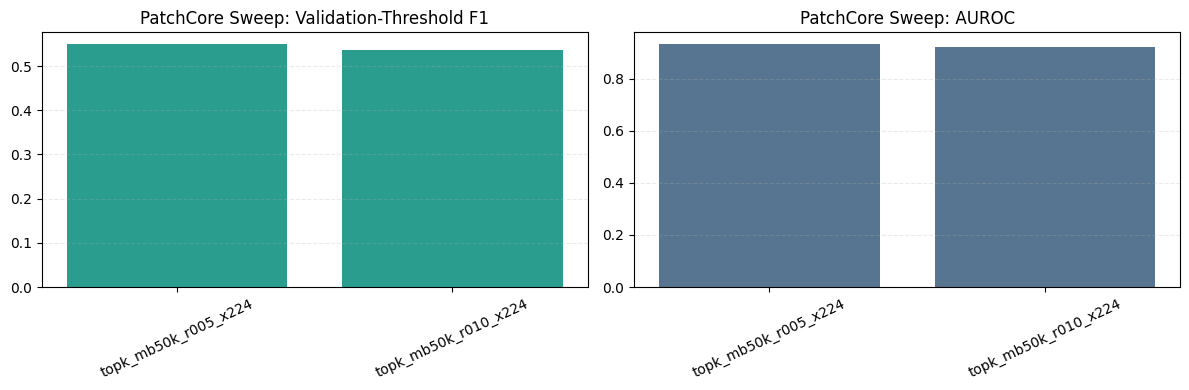

Best variant:
{
  "name": "topk_mb50k_r005_x224",
  "memory_bank_size": 600000,
  "memory_subset_images": 800,
  "patches_per_image": 784,
  "feature_dim": 1536,
  "reduction": "topk_mean",
  "topk_ratio": 0.05,
  "threshold": 0.536875206232071,
  "precision": 0.432183908045977,
  "recall": 0.752,
  "f1": 0.548905109489051,
  "auroc": 0.93068,
  "auprc": 0.6590630883520686,
  "best_sweep_threshold": 0.5587739944458008,
  "best_sweep_precision": 0.7114427860696517,
  "best_sweep_recall": 0.572,
  "best_sweep_f1": 0.6341463414634146,
  "predicted_anomalies": 435,
  "output_dir": "C:\\Users\\User\\Desktop\\Term 8\\Deep Learning\\Project\\DeepLearning-Group8\\artifacts\\x224\\patchcore-wideresnet50-multilayer\\topk_mb50k_r005_x224"
}


In [14]:
if "sweep_results_df" not in globals():
    sweep_results_df, best_row = load_existing_sweep_artifacts(output_dir)

combined_results_df = sweep_results_df.copy()
combined_results_df["output_dir"] = combined_results_df["name"].map(lambda name: str((output_dir / str(name)).resolve()))

if "follow_up_results_df" in globals() and not follow_up_results_df.empty:
    follow_up_display_df = follow_up_results_df.copy()
    follow_up_display_df["output_dir"] = follow_up_display_df["name"].map(lambda name: str((output_dir / str(name)).resolve()))
    combined_results_df = (
        pd.concat([combined_results_df, follow_up_display_df], ignore_index=True)
        .sort_values(["f1", "auroc"], ascending=False)
        .reset_index(drop=True)
    )

best_row = normalize_variant_record(combined_results_df.iloc[0].to_dict(), output_dir)

display(
    combined_results_df[
        [
            "name",
            "memory_bank_size",
            "reduction",
            "topk_ratio",
            "precision",
            "recall",
            "f1",
            "auroc",
            "auprc",
            "best_sweep_f1",
        ]
    ]
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(combined_results_df["name"], combined_results_df["f1"], color="#2a9d8f")
axes[0].set_title("PatchCore Sweep: Validation-Threshold F1")
axes[0].tick_params(axis="x", rotation=25)
axes[0].grid(axis="y", alpha=0.25, linestyle="--")

axes[1].bar(combined_results_df["name"], combined_results_df["auroc"], color="#577590")
axes[1].set_title("PatchCore Sweep: AUROC")
axes[1].tick_params(axis="x", rotation=25)
axes[1].grid(axis="y", alpha=0.25, linestyle="--")

plt.tight_layout()
plt.show()

print("Best variant:")
print(json.dumps(best_row, indent=2))


## Selected Variant Defect Breakdown

This cell loads the selected `topk_mb50k_r010_x224` all-in-one PatchCore variant and computes its defect-type recall under the deployed validation-derived threshold.


In [15]:
# DEFECT_BREAKDOWN_CELL
summary_path = output_dir / "patchcore_sweep_summary.json"
if "best_row" not in globals():
    if summary_path.exists():
        _, best_row = load_existing_sweep_artifacts(output_dir)
    else:
        raise FileNotFoundError(f"Sweep summary not found: {summary_path}. No retraining needed, but rerun the sweep summary cell first.")
else:
    best_row = normalize_variant_record(best_row, output_dir)

required_globals = ["output_dir", "test_dataset"]
missing_globals = [name for name in required_globals if name not in globals()]
if missing_globals:
    raise RuntimeError(
        "No retraining needed. Rerun the notebook setup/data cells so these objects exist: "
        + ", ".join(missing_globals)
    )

best_variant_name = str(best_row["name"])
best_threshold = float(best_row["threshold"])
variant_output_dir = Path(best_row["output_dir"])
best_scores_path = variant_output_dir / "test_scores.csv"
if not best_scores_path.exists():
    raise FileNotFoundError(f"Test scores not found for best variant: {best_scores_path}")

best_scores_df = pd.read_csv(best_scores_path).reset_index(drop=True)
analysis_df = test_dataset.metadata.reset_index(drop=True).copy()
if len(best_scores_df) != len(analysis_df):
    raise ValueError(f"Length mismatch: scores={len(best_scores_df)} metadata={len(analysis_df)}")
analysis_df["score"] = best_scores_df["score"]
analysis_df["predicted_anomaly"] = (analysis_df["score"] >= best_threshold).astype(int)

defect_breakdown_df = (
    analysis_df.loc[analysis_df["is_anomaly"] == 1]
    .groupby("defect_type")
    .agg(
        count=("defect_type", "size"),
        detected=("predicted_anomaly", "sum"),
        mean_score=("score", "mean"),
        median_score=("score", "median"),
    )
    .reset_index()
)
defect_breakdown_df["detected"] = defect_breakdown_df["detected"].astype(int)
defect_breakdown_df["missed"] = defect_breakdown_df["count"] - defect_breakdown_df["detected"]
defect_breakdown_df["recall"] = defect_breakdown_df["detected"] / defect_breakdown_df["count"]
defect_breakdown_df = defect_breakdown_df.sort_values(["recall", "count", "defect_type"], ascending=[True, False, True]).reset_index(drop=True)

display(pd.Series(best_row))
display(defect_breakdown_df)
output_path = variant_output_dir / "selected_defect_breakdown.csv"
defect_breakdown_df.to_csv(output_path, index=False)
print(f"Saved defect breakdown to {output_path}")


name                                                 topk_mb50k_r005_x224
memory_bank_size                                                   600000
memory_subset_images                                                  800
patches_per_image                                                     784
feature_dim                                                          1536
reduction                                                       topk_mean
topk_ratio                                                           0.05
threshold                                                        0.536875
precision                                                        0.432184
recall                                                              0.752
f1                                                               0.548905
auroc                                                             0.93068
auprc                                                            0.659063
best_sweep_threshold                  

,defect_type,count,detected,mean_score,median_score,missed,recall
0,Edge-Loc,53,33,0.554948,0.554587,20,0.622642
1,Scratch,15,10,0.577010,0.561583,5,0.666667
2,Loc,34,25,0.575739,0.566898,9,0.735294
3,Center,50,39,0.577360,0.583298,11,0.780000
4,Edge-Ring,84,67,0.556844,0.556229,17,0.797619
5,Donut,7,7,0.640603,0.642538,0,1.000000
6,Random,5,5,0.624461,0.634244,0,1.000000
7,Near-full,2,2,0.635663,0.635663,0,1.000000


Saved defect breakdown to C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\artifacts\x224\patchcore-wideresnet50-multilayer\topk_mb50k_r005_x224\selected_defect_breakdown.csv
